In [1]:
import pandas as pd
import numpy as np
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import PowerTransformer

from funciones import *

In [2]:
# Abrir archivo raw_data
data_folder = "../data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Ticker               503 non-null    object 
 1   Sector               500 non-null    object 
 2   MarketCap            501 non-null    float64
 3   Beta                 496 non-null    float64
 4   DividendYield        408 non-null    float64
 5   ForwardPE            501 non-null    float64
 6   trailingPegRatio     426 non-null    float64
 7   PriceToBook          501 non-null    float64
 8   EnterpriseToEbitda   467 non-null    float64
 9   ReturnOnAssets       500 non-null    float64
 10  returnOnEquity       471 non-null    float64
 11  profitMargins        500 non-null    float64
 12  operatingMargins     500 non-null    float64
 13  currentRatio         482 non-null    float64
 14  debtToEquity         450 non-null    float64
 15  revenueGrowth        497 non-null    flo

# Variables continuas

In [4]:
# Formatear market cap en billions
df["MarketCap"] = df["MarketCap"] / 10**9

In [14]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
MarketCap,501.0,127.65,404.24,6.41,21.63,40.57,86.91,4321.92
Beta,496.0,0.98,0.47,-0.10,0.66,0.98,1.25,3.71
DividendYield,408.0,2.23,1.53,0.02,1.03,1.96,3.06,8.04
ForwardPE,501.0,17.73,36.26,-634.12,12.25,17.66,23.66,141.16
trailingPegRatio,426.0,3.67,15.33,0.13,1.15,1.76,2.62,216.92
PriceToBook,501.0,5.63,80.18,-1041.90,1.84,3.26,7.10,1396.42
EnterpriseToEbitda,467.0,27.17,276.27,-2237.96,11.21,15.40,21.02,5464.29
ReturnOnAssets,500.0,0.07,0.06,-0.15,0.03,0.05,0.09,0.51
returnOnEquity,471.0,0.55,4.39,-0.86,0.09,0.15,0.29,71.50
profitMargins,500.0,0.14,0.15,-1.45,0.07,0.13,0.20,0.73


In [5]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

MarketCap               7.674361
Beta                    1.043823
DividendYield           1.012767
ForwardPE             -14.003081
trailingPegRatio       11.515798
PriceToBook             5.998854
EnterpriseToEbitda     15.301128
ReturnOnAssets          2.578768
returnOnEquity         14.984445
profitMargins          -2.443562
operatingMargins       -1.266487
currentRatio            5.051636
debtToEquity           13.444331
revenueGrowth           3.305703
shortPercentOfFloat     2.538040
dtype: float64

Cont


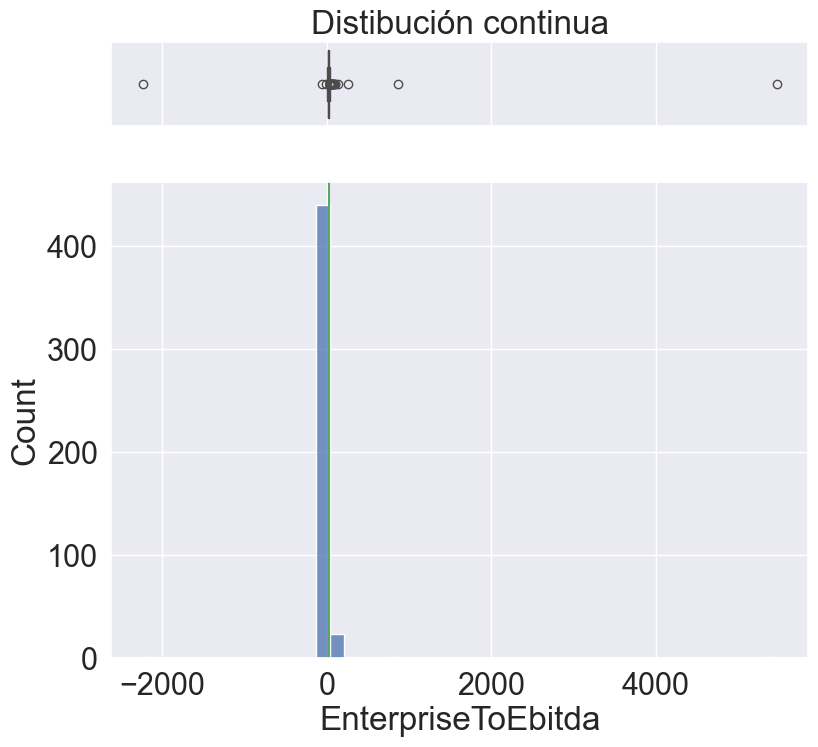

In [28]:
# Graficar
plot(df['EnterpriseToEbitda'])

In [6]:
# Variable: PriceToBook

# Transformar
pt = PowerTransformer(method='yeo-johnson', standardize=True)
df['PriceToBook_Transformed'] = pt.fit_transform(df[['PriceToBook']])

# Elimino la columna sin transformar
df.drop('PriceToBook', axis=1, inplace=True)

In [7]:
# Variable: returnOnEquity

df['returnOnEquity_Transformed'] = pt.fit_transform(df[['returnOnEquity']])
df.drop('returnOnEquity', axis=1, inplace=True)

In [8]:
# Variable: ForwardPE

df['ForwardPE_Transformed'] = pt.fit_transform(df[['ForwardPE']])
df.drop('ForwardPE', axis=1, inplace=True)

In [9]:
# Variable: MarketCap
df['MarketCap_log'] = np.log(df['MarketCap'])
df.drop('MarketCap', axis=1, inplace=True)

In [10]:
# Variable: debtToEquity
df['debtToEquity_log'] = np.log(df['debtToEquity'])
df.drop('debtToEquity', axis=1, inplace=True)

In [11]:
# Variable: trailingPegRatio
df['trailingPegRatio_log'] = np.log(df['trailingPegRatio'])
df.drop('trailingPegRatio', axis=1, inplace=True)

In [12]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

Beta                           1.043823
DividendYield                  1.012767
EnterpriseToEbitda            15.301128
ReturnOnAssets                 2.578768
profitMargins                 -2.443562
operatingMargins              -1.266487
currentRatio                   5.051636
revenueGrowth                  3.305703
shortPercentOfFloat            2.538040
PriceToBook_Transformed        4.735513
returnOnEquity_Transformed    -1.761420
ForwardPE_Transformed          3.521035
MarketCap_log                  0.991985
debtToEquity_log              -0.612114
trailingPegRatio_log           1.147135
dtype: float64

In [13]:
# Outliers
df_cont = df.select_dtypes(include="number")

In [14]:
df_winsor = df_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Beta
DividendYield
EnterpriseToEbitda
ReturnOnAssets
profitMargins
operatingMargins
currentRatio
revenueGrowth
shortPercentOfFloat
PriceToBook_Transformed
returnOnEquity_Transformed
ForwardPE_Transformed
MarketCap_log
debtToEquity_log
trailingPegRatio_log


In [17]:
df_winsor.skew()

Beta                              1.031473
DividendYield                     1.012767
ReturnOnAssets                    1.725746
profitMargins                    -0.030386
operatingMargins                 -0.364167
currentRatio                      1.476850
revenueGrowth                     1.104813
shortPercentOfFloat               1.663579
PriceToBook_Transformed           0.177536
returnOnEquity_Transformed        0.549120
ForwardPE_Transformed             0.555185
MarketCap_log                     0.991985
debtToEquity_log                 -0.509565
trailingPegRatio_log              0.463419
EnterpriseToEbitda_Transformed    1.197903
dtype: float64

Cont


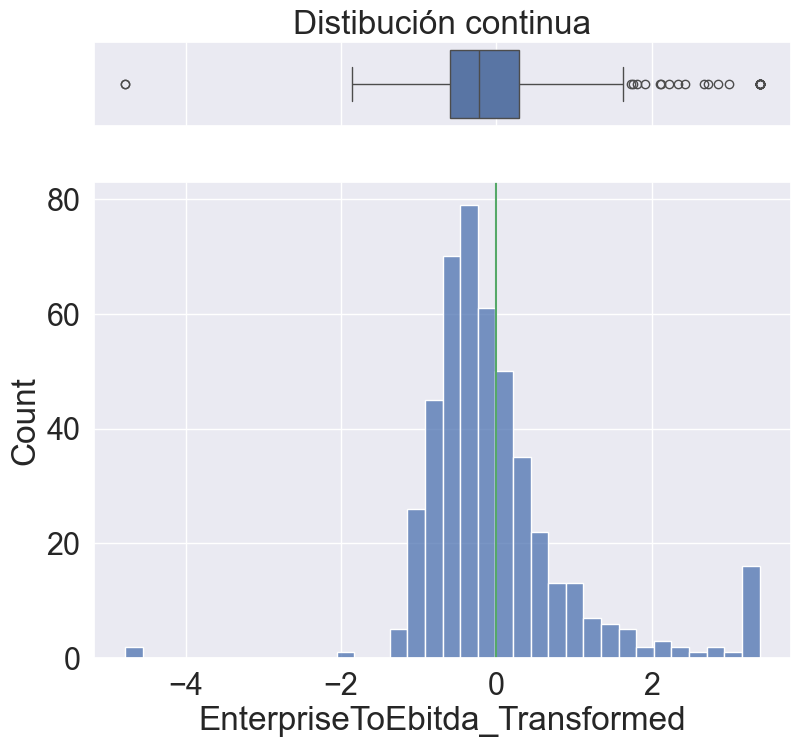

In [ ]:
plot(df_winsor['EnterpriseToEbitda'])

In [20]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
alpha,100.0,2.929874e+00,9.906390,-18.387055,-3.854778,2.454444,8.690918,42.646676
rangePosition,100.0,6.854260e+01,23.671129,5.730000,58.922500,75.465000,85.477500,99.730000
avgReturn,100.0,1.223400e+01,11.027653,-7.630000,6.290000,11.655000,17.642500,54.420000
annualizedVol,100.0,2.834250e+01,8.145430,15.810000,23.312500,26.685000,31.972500,59.870000
sharpeRatio,100.0,2.979000e-01,0.359992,-0.400000,0.080000,0.270000,0.492500,1.330000
Beta,100.0,8.866500e-01,0.474125,0.010000,0.421750,0.911500,1.222500,2.375000
DividendYield,89.0,2.252693e+00,1.493317,0.019700,0.890000,2.220000,3.010000,6.520000
EnterpriseToEbitda,89.0,1.814185e+01,16.669335,-64.613000,11.402000,16.068000,21.444000,94.362000
ReturnOnAssets,100.0,7.826270e-02,0.072357,-0.019990,0.034205,0.062805,0.109047,0.511880
profitMargins,100.0,1.782499e-01,0.128786,-0.234380,0.084505,0.159300,0.283062,0.556030


In [16]:
# Transformar post winsorizacion
# Variable: EnterpriseToEbitda
df_winsor['EnterpriseToEbitda_Transformed'] = pt.fit_transform(df_winsor[['EnterpriseToEbitda']])
df_winsor.drop('EnterpriseToEbitda', axis=1, inplace=True)

# Variables Categoricas

In [19]:
df_non_numeric = df.select_dtypes(exclude='number')

In [20]:
# Valores unicos
df_non_numeric.nunique()

Ticker    503
Sector     11
dtype: int64

In [21]:
# Convertir Sector a category
df_non_numeric['Sector'] = df_non_numeric['Sector'].astype('category')

In [22]:
df_non_numeric['Sector'].value_counts()

Sector
Technology                82
Industrials               73
Financial Services        69
Healthcare                60
Consumer Cyclical         53
Consumer Defensive        35
Real Estate               31
Utilities                 31
Communication Services    24
Energy                    22
Basic Materials           20
Name: count, dtype: int64

In [31]:
df_non_numeric[df_non_numeric['Sector'].isnull()]

,Ticker,Sector
61,BRK.B,NaN
76,BF.B,NaN
200,FISV,NaN


In [32]:
# Asignar manualmente el sector a los 3 tickers con valor nulo
df_non_numeric.loc[df_non_numeric['Ticker'] == 'BRK.B', 'Sector'] = 'Financial Services'
df_non_numeric.loc[df_non_numeric['Ticker'] == 'BF.B', 'Sector'] = 'Consumer Cyclical'
df_non_numeric.loc[df_non_numeric['Ticker'] == 'FISV', 'Sector'] = 'Technology'

In [33]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_non_numeric, df_winsor], axis=1)
df_combined.head()

,Ticker,Sector,Beta,DividendYield,ReturnOnAssets,profitMargins,operatingMargins,currentRatio,revenueGrowth,shortPercentOfFloat,PriceToBook_Transformed,returnOnEquity_Transformed,ForwardPE_Transformed,MarketCap_log,debtToEquity_log,trailingPegRatio_log,EnterpriseToEbitda_Transformed
0,MMM,Industrials,1.131,2.03,0.07584,0.13027,0.12408,1.708,0.020,0.0156,0.147844,1.451150,-0.249818,4.391990,5.622710,0.399581,-0.319381
1,AOS,Industrials,1.304,1.97,0.14257,0.14260,0.17951,1.497,0.000,0.0557,-0.001384,0.354731,-0.250568,2.284418,2.395529,0.379190,-0.517045
2,ABT,Healthcare,0.744,2.30,0.06630,0.14718,0.21616,1.576,0.044,0.0099,-0.021912,-0.243308,-0.173157,5.249025,3.287917,NaN,-0.137957
3,ABBV,Healthcare,0.334,3.01,0.09807,0.06910,0.34108,0.671,0.100,0.0129,-0.248735,2.674521,-0.374620,6.008502,NaN,-0.596384,-0.159706
4,ACN,Technology,1.251,3.03,0.11125,0.10761,0.16974,1.411,0.060,0.0276,-0.013968,0.215620,-0.366858,4.892826,3.246258,0.511086,-0.649482


# Missings

In [34]:
df_combined.isnull().sum()

Ticker                             0
Sector                             0
Beta                               7
DividendYield                     95
ReturnOnAssets                     3
profitMargins                      3
operatingMargins                   3
currentRatio                      21
revenueGrowth                      6
shortPercentOfFloat                6
PriceToBook_Transformed            2
returnOnEquity_Transformed        32
ForwardPE_Transformed              2
MarketCap_log                      2
debtToEquity_log                  53
trailingPegRatio_log              77
EnterpriseToEbitda_Transformed    36
dtype: int64

In [35]:
# DividendYield: imputar 0
df_combined['DividendYield'] = df_combined['DividendYield'].fillna(0)

In [36]:
# Resto de las continuas: imputar multivariable con IterativeImputer
df_cont = df_combined.select_dtypes(include='number')
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

In [37]:
df_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Beta                            503 non-null    float64
 1   DividendYield                   503 non-null    float64
 2   ReturnOnAssets                  503 non-null    float64
 3   profitMargins                   503 non-null    float64
 4   operatingMargins                503 non-null    float64
 5   currentRatio                    503 non-null    float64
 6   revenueGrowth                   503 non-null    float64
 7   shortPercentOfFloat             503 non-null    float64
 8   PriceToBook_Transformed         503 non-null    float64
 9   returnOnEquity_Transformed      503 non-null    float64
 10  ForwardPE_Transformed           503 non-null    float64
 11  MarketCap_log                   503 non-null    float64
 12  debtToEquity_log                503 

In [38]:
df_final = pd.concat([df_imputed, df_combined.select_dtypes(exclude='number')], axis=1)

In [39]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Beta                            503 non-null    float64 
 1   DividendYield                   503 non-null    float64 
 2   ReturnOnAssets                  503 non-null    float64 
 3   profitMargins                   503 non-null    float64 
 4   operatingMargins                503 non-null    float64 
 5   currentRatio                    503 non-null    float64 
 6   revenueGrowth                   503 non-null    float64 
 7   shortPercentOfFloat             503 non-null    float64 
 8   PriceToBook_Transformed         503 non-null    float64 
 9   returnOnEquity_Transformed      503 non-null    float64 
 10  ForwardPE_Transformed           503 non-null    float64 
 11  MarketCap_log                   503 non-null    float64 
 12  debtToEquity_log      

In [40]:
df_final.select_dtypes(include='number').skew()

Beta                              1.013502
DividendYield                     0.983346
ReturnOnAssets                    1.726397
profitMargins                    -0.030124
operatingMargins                 -0.363943
currentRatio                      1.498899
revenueGrowth                     1.105041
shortPercentOfFloat               1.640820
PriceToBook_Transformed           0.174715
returnOnEquity_Transformed        0.564627
ForwardPE_Transformed             0.554135
MarketCap_log                     0.991917
debtToEquity_log                 -0.430882
trailingPegRatio_log              0.429050
EnterpriseToEbitda_Transformed    1.227361
dtype: float64

In [41]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")